In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tab_sdpt_fp = pd.read_csv("/share/homes/boyerma/FastSDPCertification/results/benchmark/9x100-0.026/ECML-SDPu-PP/results_fp_30_data.csv")
#tab_sdpt_fp = pd.read_csv("/share/homes/boyerma/FastSDPCertification/results/benchmark/9x100-0.026/ECML-SDPu-PP/results_fp_7_data.csv")
# tab_sdpt_fp = tab_sdpt_fp[tab_sdpt_fp['data_index']!=3].copy()

# tab_sdpt_fp = tab_sdpt_fp[tab_sdpt_fp['data_index'].isin([ 0,  1,  2, 3, 87, 25, 26, 27])]
tab_sdpt_fp = tab_sdpt_fp.dropna(subset = "time", axis = 0)
tab_sdpt_fp = tab_sdpt_fp.sort_values(
    by=["data_index", "target"]
)
tab_sdpt_fp = tab_sdpt_fp.reset_index(drop= True)


In [3]:
#tab_sdpt_pp = pd.read_csv("/share/homes/boyerma/FastSDPCertification/results/benchmark/9x100-0.026/ECML-SDPu-PP/results_pp_8_data.csv")
tab_sdpt_pp = pd.read_csv("/share/homes/boyerma/FastSDPCertification/results/benchmark/9x100-0.026/ECML-SDPu-PP/results_pp_30_data.csv")
#tab_sdpt_pp = tab_sdpt_pp[tab_sdpt_pp['data_index']!=3].copy()
# tab_sdpt_pp = tab_sdpt_pp[tab_sdpt_pp['data_index'].isin([ 0,  1,  2, 3, 87, 25, 26, 27])]
tab_sdpt_pp = tab_sdpt_pp.dropna(subset = "time", axis = 0)

tab_sdpt_pp = tab_sdpt_pp.sort_values(
    by=["data_index", "target"]
)
tab_sdpt_pp = tab_sdpt_pp.reset_index(drop = True)



In [4]:
# tab_sdpt_pp[tab_sdpt_pp["data_index"]==22][tab_sdpt_pp['target']==5]

# tab_sdpt_pp=tab_sdpt_pp.drop(index=202)

In [5]:
tab_sdpt_fp.shape

(30, 32)

In [6]:
meme_ordre = (
    tab_sdpt_fp[["data_index", "target"]]
    .equals(tab_sdpt_pp[["data_index", "target"]])
)
meme_ordre


True

In [7]:
columns_per_model = ['Nb_constraints', 'Nb_variables', 'time', 'optimal_value']
new_name = {"Nb_constraints" : "Nb constraints", "Nb_variables" : "Nb variables", "time" : "Time", "optimal_value" : "Optimal Value" }
cols = ['data_index', 'target']
for col in columns_per_model:
    cols.append(f'PP_{col}')
    cols.append(f'FP_{col}')

In [8]:
for data_index in range(100):
    for target in range(10):
        nb_fp = ((tab_sdpt_fp["data_index"] == data_index) & (tab_sdpt_fp["target"] == target)).sum()
        nb_pp = ((tab_sdpt_pp["data_index"] == data_index) & (tab_sdpt_pp["target"] == target)).sum()
        if nb_fp != nb_pp:
            print(f"Erreur sur data_index={data_index}, target = {target} : nb_fp = {nb_fp}, nb_pp = {nb_pp}")

In [9]:
tab_sdpt_fp['Nb_variables'].value_counts()

Series([], Name: count, dtype: int64)

In [10]:
tab_sdpt_fp[tab_sdpt_fp['data_index']==13][columns_per_model].head(20)

,Nb_constraints,Nb_variables,time,optimal_value


In [11]:
for data_index in range(100):
    for target in range(10):
        nb_pp = ((tab_sdpt_pp["data_index"] == data_index) & (tab_sdpt_pp["target"] == target)).sum()
        nb_fp = ((tab_sdpt_fp["data_index"] == data_index) & (tab_sdpt_fp["target"] == target)).sum()
        if nb_pp != nb_fp :
            print(f"Différence sur data_index={data_index}, target = {target} : nb_pp = {nb_pp}, nb_fp = {nb_fp}")

In [12]:
tab_diff = pd.DataFrame()
tab_diff['data_index'] = tab_sdpt_fp['data_index']
tab_diff['target'] = tab_sdpt_fp['target']
tab_diff[['Nb stable inactives', 'Nb stable actives']] = tab_sdpt_fp[['Nb_stable_inactives', 'Nb_stable_actives']].copy()
tab_diff['Nb unstable'] = 900 - (tab_diff['Nb stable actives'] + tab_diff['Nb stable inactives'])
tab_diff["Stable active/Unstable"] = tab_diff['Nb stable actives']/tab_diff['Nb unstable']
tab_diff["Stable active/Inactive"] = tab_diff['Nb stable actives']/tab_diff['Nb stable inactives']
for criterium in columns_per_model :
    tab_diff[new_name[criterium]] = tab_sdpt_fp[criterium] - tab_sdpt_pp[criterium]
tab_diff["Proportional Time Gain"] = (tab_sdpt_fp['time'] - tab_sdpt_pp['time']) / tab_sdpt_pp['time']
tab_diff['Relative Gap'] = (tab_sdpt_fp['optimal_value'] - tab_sdpt_pp['optimal_value']) / tab_sdpt_pp['optimal_value']

In [13]:
tab_diff

,data_index,target,Nb stable inactives,Nb stable actives,Nb unstable,Stable active/Unstable,Stable active/Inactive,Nb constraints,Nb variables,Time,Optimal Value,Proportional Time Gain,Relative Gap
0,0,NaN,478,260,162,1.604938,0.543933,-70227,NaN,-5481.722396,-2.159728,-0.749908,-1.653685
1,1,NaN,474,265,161,1.645963,0.559072,-79353,NaN,-6905.787781,-2.201938,-0.943338,-1.948849
2,2,NaN,514,278,108,2.574074,0.540856,-61323,NaN,-5605.822189,-0.331011,-0.767804,-0.079777
3,3,NaN,492,285,123,2.317073,0.579268,-72969,NaN,-5993.778116,-1.460458,-0.823710,-0.302398
4,4,NaN,489,273,138,1.978261,0.558282,-70434,NaN,-3442.515335,-5.408220,-0.467244,-0.641123
5,5,NaN,487,270,143,1.888112,0.554415,-61299,NaN,1088.002141,-5.024870,0.146445,-0.860368
6,6,NaN,451,261,188,1.388298,0.578714,-71667,NaN,-3418.052071,-6.905645,-0.456678,-1.905924
7,7,NaN,427,228,245,0.930612,0.533958,-51486,NaN,-204.442613,-8.962768,-0.027455,-2.305274
8,8,NaN,505,295,100,2.950000,0.584158,-75513,NaN,-6540.696497,-0.992660,-0.983488,-0.168608
9,9,NaN,484,268,148,1.810811,0.553719,-66771,NaN,-4671.774429,-1.145527,-0.647771,-0.322441


In [24]:
abscisse = 'Stable active/Unstable'
criteria = ['Proportional Time Gain', 'Relative Gap', 'Time', 'Nb constraints', 'Optimal Value']
#criteria  = ['Proportional Time Gain', 'Optimal Value']

quantiles = 6

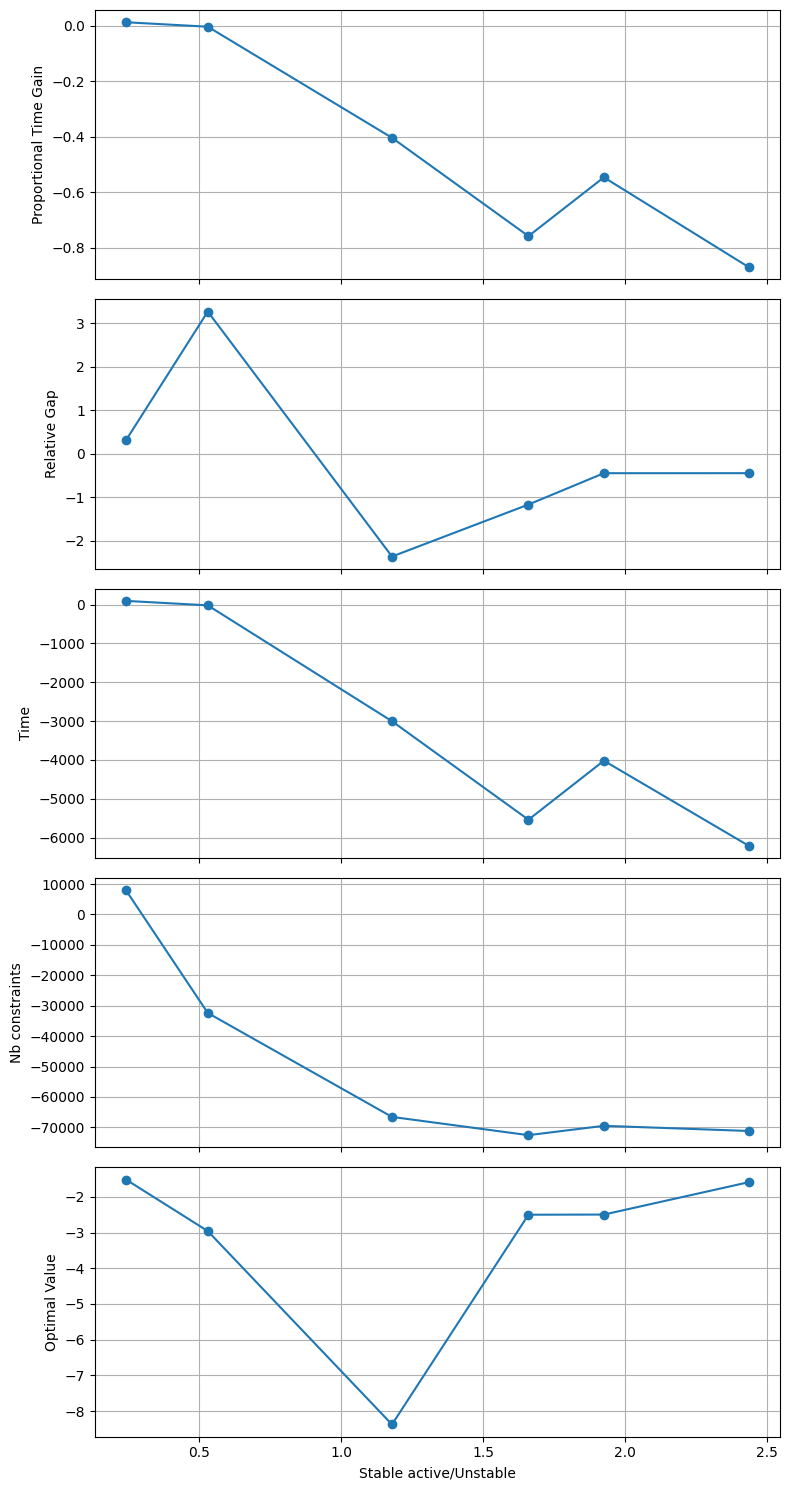

In [25]:
df = tab_diff[[abscisse] + criteria].dropna().copy()

# 10 blocs
df["bin"] = pd.qcut(df[abscisse], q=quantiles, labels=False, duplicates="drop")

# Moyennes par bloc
df_plot = df.groupby("bin").mean().reset_index(drop=True)

n = len(criteria)
fig, axes = plt.subplots(n, 1, figsize=(8, 3*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, crit in zip(axes, criteria):
    ax.plot(df_plot[abscisse], df_plot[crit], marker="o")
    ax.set_ylabel(crit)
    ax.grid(True)

axes[-1].set_xlabel(abscisse)
#fig.suptitle("Moyennes par blocs (10 quantiles)", y=1.02)

plt.tight_layout()
plt.show()

In [26]:
print(criteria)

['Proportional Time Gain', 'Relative Gap', 'Time', 'Nb constraints', 'Optimal Value']


In [27]:
fontsize = 18

df = tab_diff[[abscisse] + criteria].dropna().copy()



# 10 blocs
df["bin"] = pd.qcut(df[abscisse], q=quantiles, labels=False, duplicates="drop")



Criteria:  Proportional Time Gain
Criteria:  Relative Gap
Criteria:  Time
Criteria:  Nb constraints
Criteria:  Optimal Value


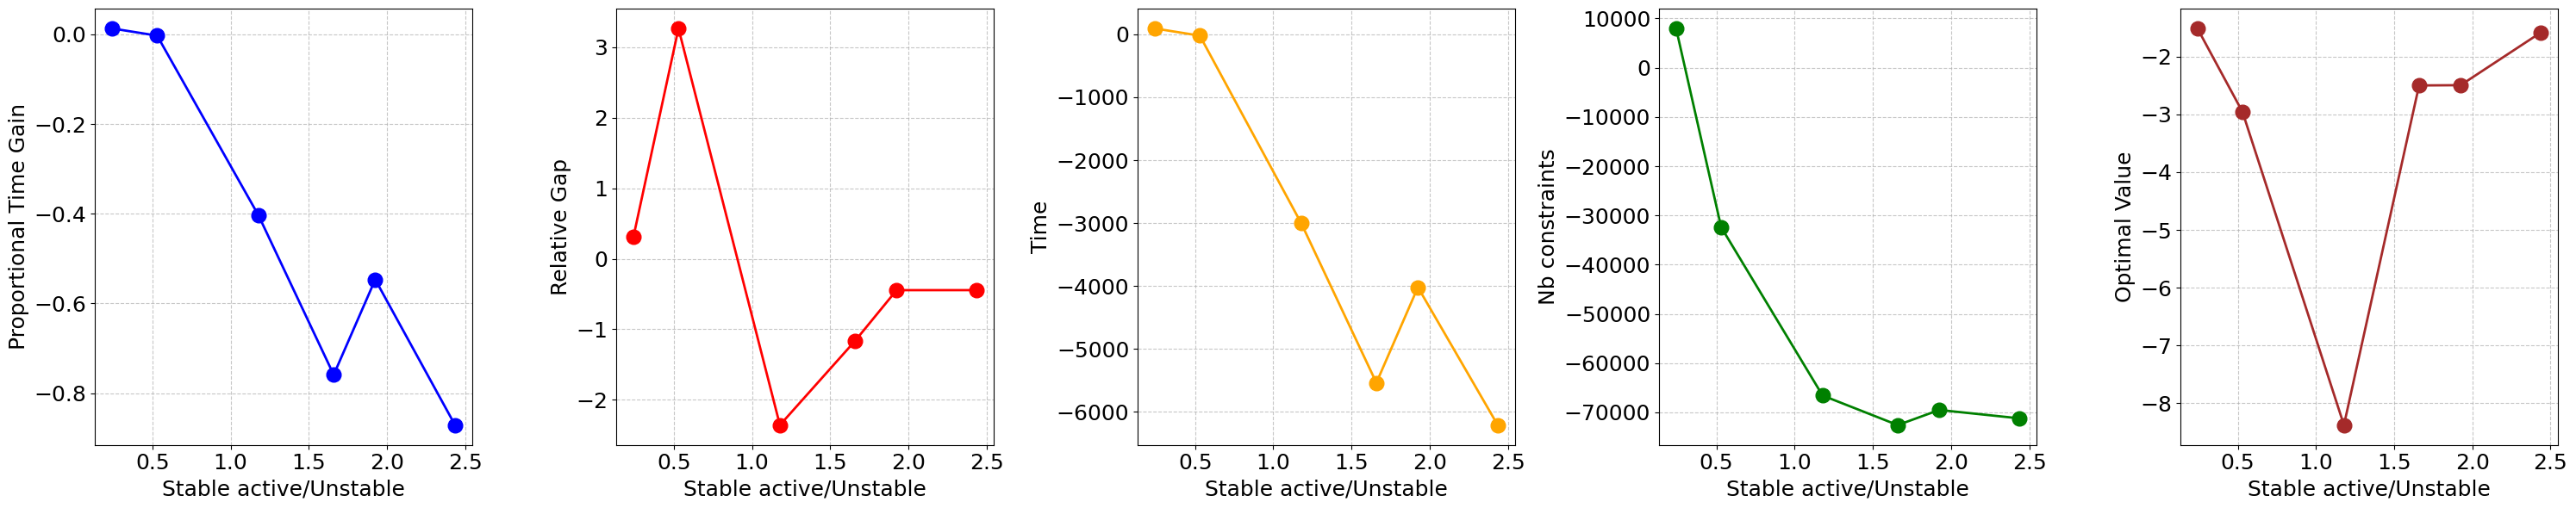

In [28]:
# Moyennes par bloc
df_plot = df.groupby("bin").mean().reset_index(drop=True)

n = len(criteria)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))

if n == 1:
    axes = [axes]

colors = ['blue', 'red', 'orange', 'green', 'brown']

for ax, crit, color in zip(axes, criteria, colors):
    print('Criteria: ', crit)
    ax.plot(df_plot[abscisse], df_plot[crit], 'o-', color=color,
            linewidth=2, markersize=12)
    ax.set_xlabel(abscisse, fontsize=fontsize)
    ax.set_ylabel(crit, fontsize=fontsize)
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()